# Exploração inicial do dataset benchmark Electricity Load Diagrams 2011–2014

Este notebook apresenta uma exploração inicial do dataset benchmark **Electricity Load Diagrams 2011–2014**, amplamente utilizado em estudos de análise de séries temporais e deteção de anomalias.

Objetivos desta exploração:

- compreender a estrutura do dataset;
- avaliar a qualidade dos dados;
- observar o comportamento temporal das séries;
- realizar uma análise estatística inicial dos consumos;
- comparar este benchmark com os datasets municipais analisados anteriormente.

In [1]:
import zipfile
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import autocorrelation_plot

plt.rcParams["figure.figsize"] = (12, 4)
sns.set_theme(style="whitegrid")

In [2]:
data_raw_path = Path("../data_raw")
data_raw_path

WindowsPath('../data_raw')

In [3]:
list(data_raw_path.iterdir())

[WindowsPath('../data_raw/electricityloaddiagrams20112014.zip')]

In [4]:
zip_path = data_raw_path / "electricityloaddiagrams20112014.zip"
zip_path

WindowsPath('../data_raw/electricityloaddiagrams20112014.zip')

In [5]:
with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())

['LD2011_2014.txt', '__MACOSX/', '__MACOSX/._LD2011_2014.txt']


In [6]:
with zipfile.ZipFile(zip_path) as z:
    with z.open(z.namelist()[0]) as f:
        df_benchmark = pd.read_csv(f, sep=";", decimal=",")

In [7]:
df_benchmark.head()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df_benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Columns: 371 entries, Unnamed: 0 to MT_370
dtypes: float64(370), object(1)
memory usage: 397.0+ MB


In [9]:
df_benchmark.shape

(140256, 371)

In [10]:
df_benchmark.columns[:10]

Index(['Unnamed: 0', 'MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005',
       'MT_006', 'MT_007', 'MT_008', 'MT_009'],
      dtype='object')

### Estrutura do dataset

Este dataset encontra-se organizado em formato matricial:

- a primeira coluna corresponde ao instante temporal;
- cada coluna seguinte corresponde a um cliente/contador;
- cada linha representa o consumo registado num determinado instante.

Ao contrário dos datasets municipais anteriormente analisados, este benchmark já se encontra num formato mais próximo de uma matriz de séries temporais.

In [11]:
df_benchmark.rename(columns={df_benchmark.columns[0]: "tstamp"}, inplace=True)

In [12]:
df_benchmark["tstamp"] = pd.to_datetime(df_benchmark["tstamp"])

In [13]:
df_benchmark = df_benchmark.sort_values("tstamp")

In [14]:
print("Início:", df_benchmark["tstamp"].min())
print("Fim:", df_benchmark["tstamp"].max())

Início: 2011-01-01 00:15:00
Fim: 2015-01-01 00:00:00


In [15]:
print("Número de séries:", len(df_benchmark.columns) - 1)

Número de séries: 370


In [16]:
df_benchmark.isna().sum().head()

tstamp    0
MT_001    0
MT_002    0
MT_003    0
MT_004    0
dtype: int64

In [17]:
df_pivot_benchmark = df_benchmark.set_index("tstamp")
df_pivot_benchmark.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
tstamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
df_pivot_benchmark.shape

(140256, 370)

In [19]:
missing_pct_benchmark = df_pivot_benchmark.isna().mean() * 100
missing_pct_benchmark.sort_values().head(10)

MT_001    0.0
MT_252    0.0
MT_251    0.0
MT_250    0.0
MT_249    0.0
MT_248    0.0
MT_247    0.0
MT_246    0.0
MT_245    0.0
MT_244    0.0
dtype: float64

In [20]:
zeros_pct_benchmark = (df_pivot_benchmark == 0).mean() * 100
zeros_pct_benchmark.sort_values(ascending=False).head(10)

MT_178    88.637919
MT_133    86.812685
MT_181    79.397673
MT_109    78.306097
MT_116    78.305384
MT_112    77.921087
MT_160    77.344285
MT_347    76.591376
MT_337    76.180698
MT_115    75.920460
dtype: float64

### Observações iniciais

A análise inicial do benchmark permite avaliar:

- número de séries disponíveis;
- período temporal coberto;
- presença de valores em falta;
- percentagem de zeros por série.

A análise da percentagem de zeros é particularmente importante neste dataset, uma vez que algumas séries podem apresentar períodos prolongados sem consumo.

In [21]:
serie_exemplo_benchmark = df_pivot_benchmark.iloc[:, 0]
nome_serie_exemplo = df_pivot_benchmark.columns[0]

nome_serie_exemplo

'MT_001'

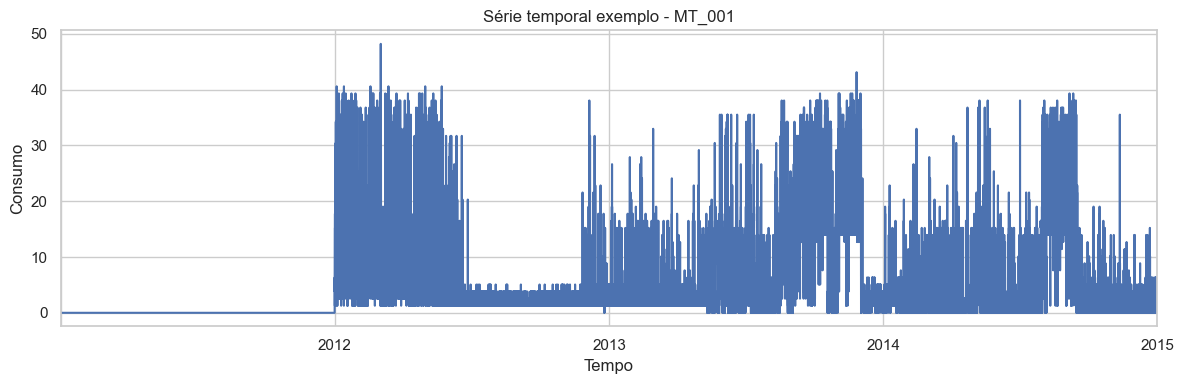

In [22]:
plt.figure(figsize=(12, 4))
serie_exemplo_benchmark.plot()

plt.title(f"Série temporal exemplo - {nome_serie_exemplo}")
plt.xlabel("Tempo")
plt.ylabel("Consumo")

plt.tight_layout()
plt.show()

In [23]:
df_pivot_benchmark.index.to_series().diff().value_counts().head()

tstamp
0 days 00:15:00    140255
Name: count, dtype: int64

## Análise estatística inicial

Para complementar a exploração anterior, seguem-se algumas análises estatísticas descritivas do benchmark, incluindo consumos médios, distribuição dos valores e agregações temporais.

In [24]:
print("Número total de timestamps:", len(df_pivot_benchmark))
print("Número de séries:", df_pivot_benchmark.shape[1])
print("Período temporal:", df_pivot_benchmark.index.min(), "até", df_pivot_benchmark.index.max())

Número total de timestamps: 140256
Número de séries: 370
Período temporal: 2011-01-01 00:15:00 até 2015-01-01 00:00:00


In [25]:
estatisticas_globais_benchmark = df_pivot_benchmark.stack().describe()
estatisticas_globais_benchmark

count    5.189472e+07
mean     5.285323e+02
std      3.224374e+03
min      0.000000e+00
25%      1.992528e+01
50%      9.950322e+01
75%      2.766871e+02
max      1.928000e+05
dtype: float64

In [26]:
consumo_medio_por_serie = df_pivot_benchmark.mean().sort_values(ascending=False)
consumo_medio_por_serie.head(10)

MT_362    37607.987537
MT_196    20744.150874
MT_279    12038.971232
MT_370     8722.355145
MT_208     6662.030067
MT_228     5782.656826
MT_220     2951.449898
MT_364     2940.031734
MT_194     2675.000006
MT_241     2616.867076
dtype: float64

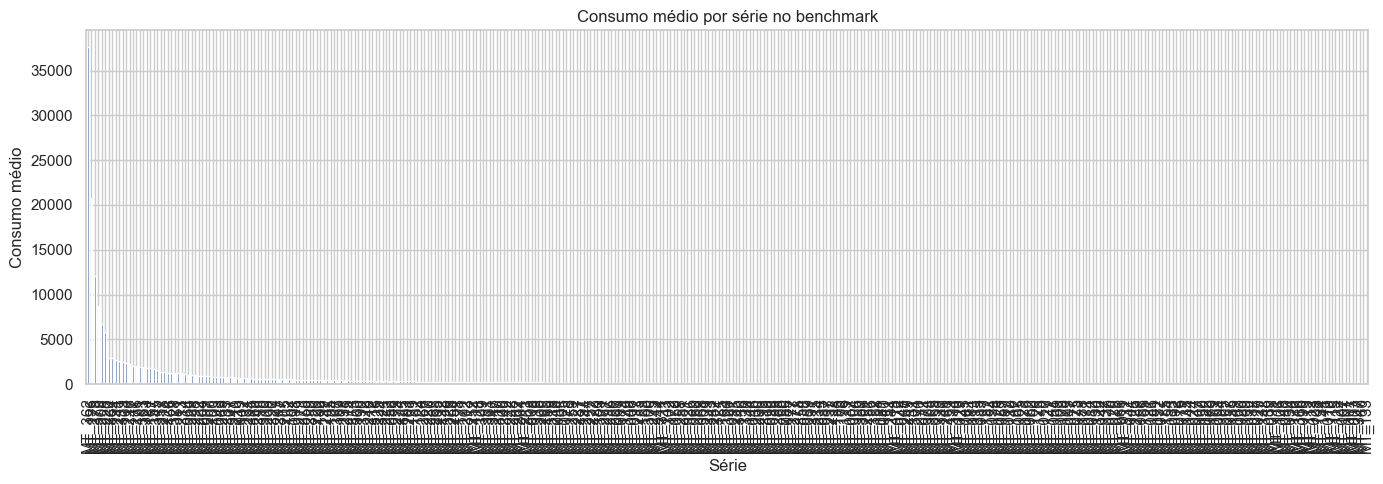

In [27]:
plt.figure(figsize=(14, 5))
consumo_medio_por_serie.plot(kind="bar")
plt.title("Consumo médio por série no benchmark")
plt.xlabel("Série")
plt.ylabel("Consumo médio")
plt.tight_layout()
plt.show()

In [28]:
consumo_medio_global_benchmark = df_pivot_benchmark.mean().mean()
print("Consumo médio global:", consumo_medio_global_benchmark)

Consumo médio global: 528.5322770982516


In [29]:
consumo_diario_benchmark = df_pivot_benchmark.resample("D").sum()
consumo_diario_benchmark.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
tstamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


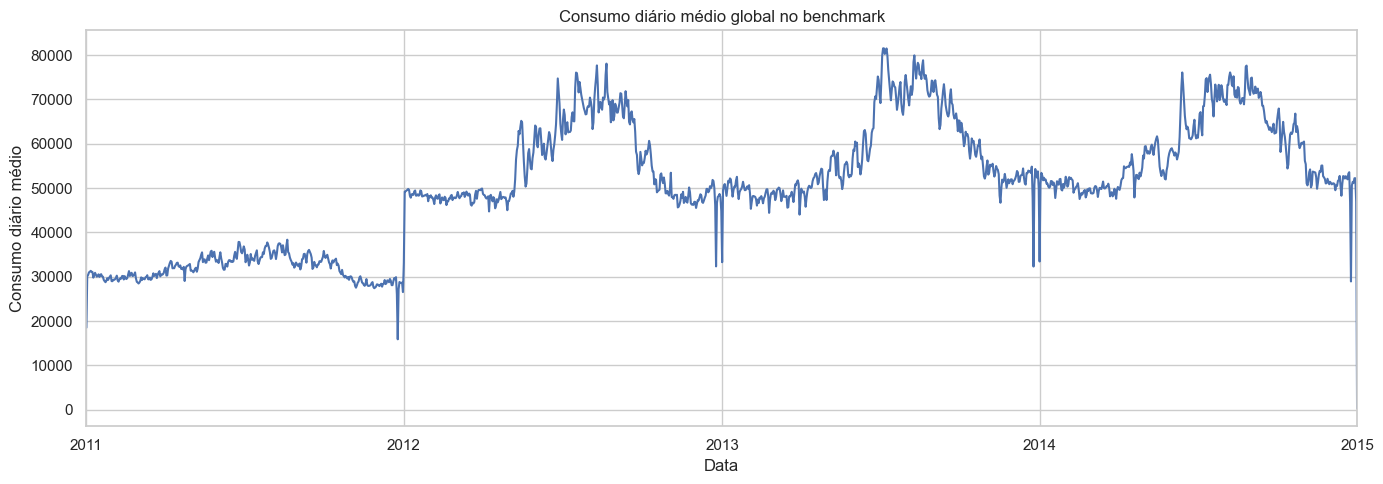

In [30]:
plt.figure(figsize=(14, 5))
consumo_diario_benchmark.mean(axis=1).plot()
plt.title("Consumo diário médio global no benchmark")
plt.xlabel("Data")
plt.ylabel("Consumo diário médio")
plt.tight_layout()
plt.show()

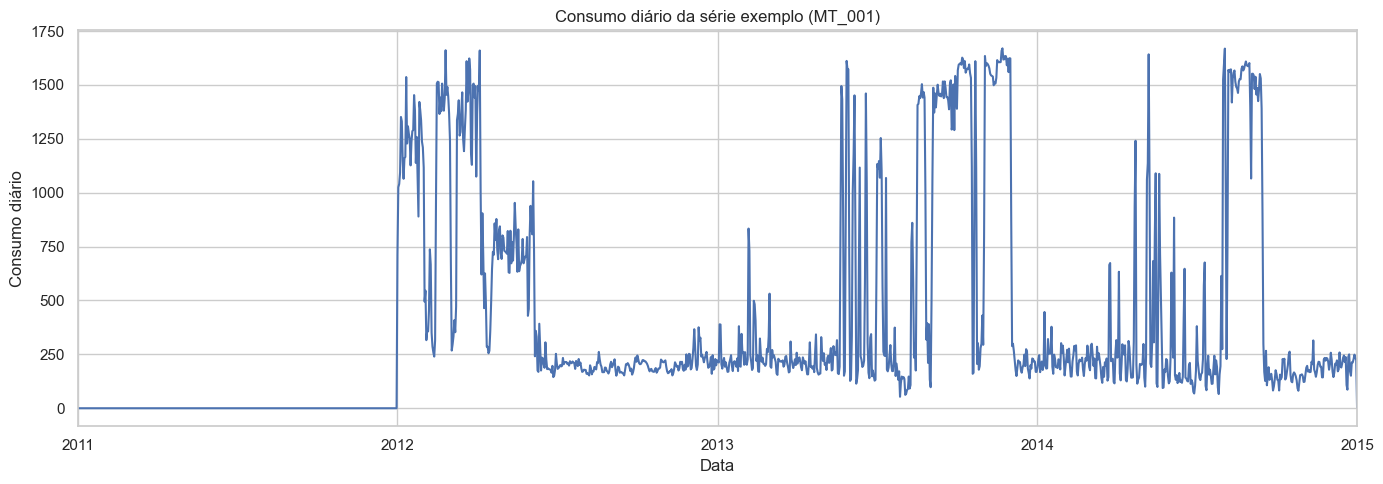

In [31]:
plt.figure(figsize=(14, 5))
consumo_diario_benchmark[nome_serie_exemplo].plot()
plt.title(f"Consumo diário da série exemplo ({nome_serie_exemplo})")
plt.xlabel("Data")
plt.ylabel("Consumo diário")
plt.tight_layout()
plt.show()

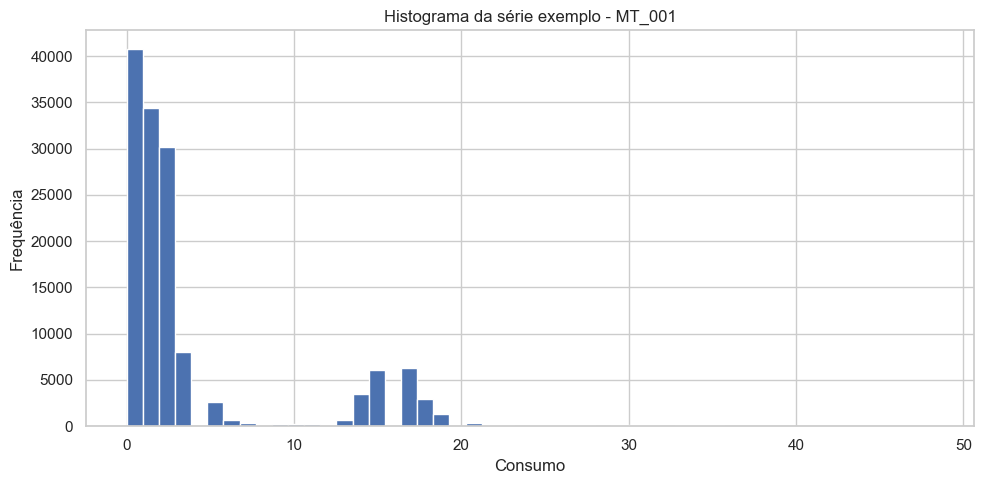

In [32]:
plt.figure(figsize=(10, 5))
plt.hist(serie_exemplo_benchmark.dropna(), bins=50)
plt.title(f"Histograma da série exemplo - {nome_serie_exemplo}")
plt.xlabel("Consumo")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

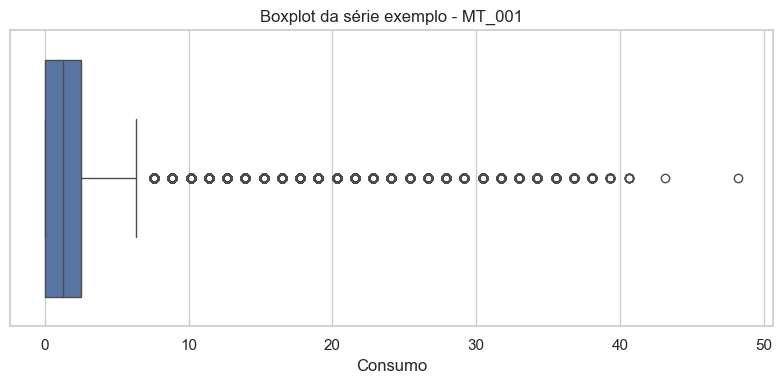

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=serie_exemplo_benchmark.dropna())
plt.title(f"Boxplot da série exemplo - {nome_serie_exemplo}")
plt.xlabel("Consumo")
plt.tight_layout()
plt.show()

In [34]:
serie_exemplo_benchmark.describe()

count    140256.000000
mean          3.970785
std           5.983965
min           0.000000
25%           0.000000
50%           1.269036
75%           2.538071
max          48.223350
Name: MT_001, dtype: float64

### Agregações temporais

As agregações seguintes permitem observar tendências e possíveis padrões sazonais em diferentes escalas temporais.

In [35]:
serie_exemplo_diaria = serie_exemplo_benchmark.resample("D").mean()
serie_exemplo_semanal = serie_exemplo_benchmark.resample("W").mean()
serie_exemplo_mensal = serie_exemplo_benchmark.resample("M").mean()

C:\Users\gui30\AppData\Local\Temp\ipykernel_12824\1853885688.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  serie_exemplo_mensal = serie_exemplo_benchmark.resample("M").mean()


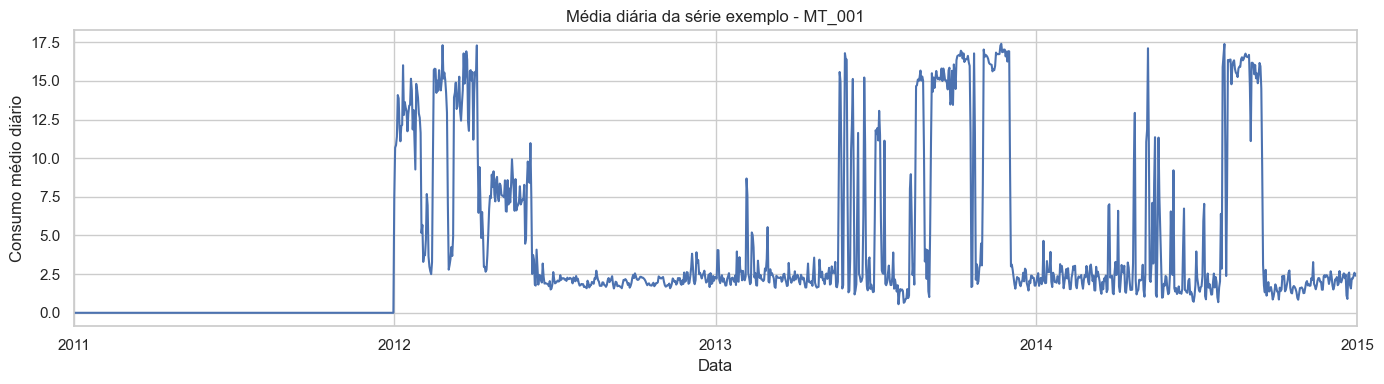

In [36]:
plt.figure(figsize=(14, 4))
serie_exemplo_diaria.plot()
plt.title(f"Média diária da série exemplo - {nome_serie_exemplo}")
plt.xlabel("Data")
plt.ylabel("Consumo médio diário")
plt.tight_layout()
plt.show()

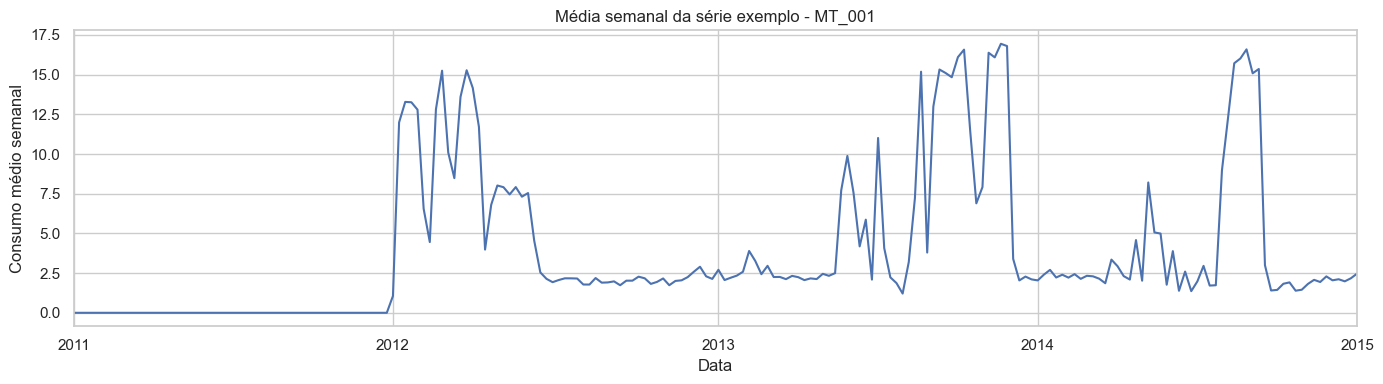

In [37]:
plt.figure(figsize=(14, 4))
serie_exemplo_semanal.plot()
plt.title(f"Média semanal da série exemplo - {nome_serie_exemplo}")
plt.xlabel("Data")
plt.ylabel("Consumo médio semanal")
plt.tight_layout()
plt.show()

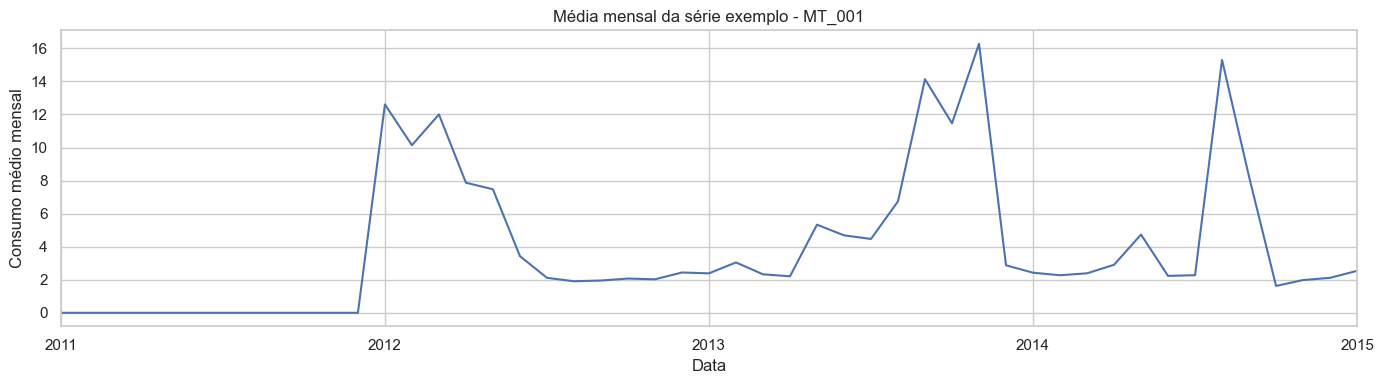

In [38]:
plt.figure(figsize=(14, 4))
serie_exemplo_mensal.plot()
plt.title(f"Média mensal da série exemplo - {nome_serie_exemplo}")
plt.xlabel("Data")
plt.ylabel("Consumo médio mensal")
plt.tight_layout()
plt.show()

### Autocorrelação

A autocorrelação permite observar dependências temporais e padrões regulares na série temporal exemplo.

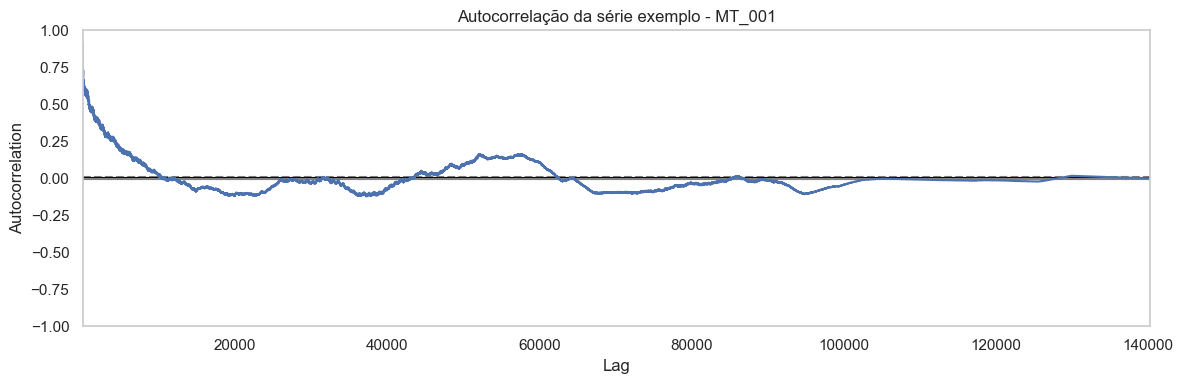

In [39]:
plt.figure(figsize=(12, 4))
autocorrelation_plot(serie_exemplo_benchmark.dropna())
plt.title(f"Autocorrelação da série exemplo - {nome_serie_exemplo}")
plt.tight_layout()
plt.show()

### Perfil médio diário

Para observar padrões médios ao longo de um dia típico, calcula-se o perfil médio diário agregando os consumos por hora do dia.

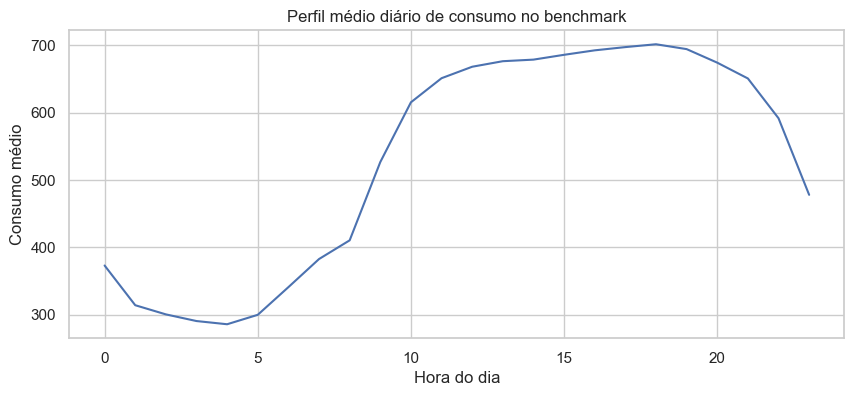

In [40]:
perfil_diario_benchmark = df_pivot_benchmark.copy()

perfil_diario_benchmark["hora"] = perfil_diario_benchmark.index.hour

perfil_medio_benchmark = perfil_diario_benchmark.groupby("hora").mean().mean(axis=1)

plt.figure(figsize=(10, 4))
perfil_medio_benchmark.plot()

plt.title("Perfil médio diário de consumo no benchmark")
plt.xlabel("Hora do dia")
plt.ylabel("Consumo médio")

plt.show()

### Distribuição da percentagem de zeros por série

A percentagem de zeros por série ajuda a identificar clientes com atividade reduzida ou períodos extensos sem consumo.

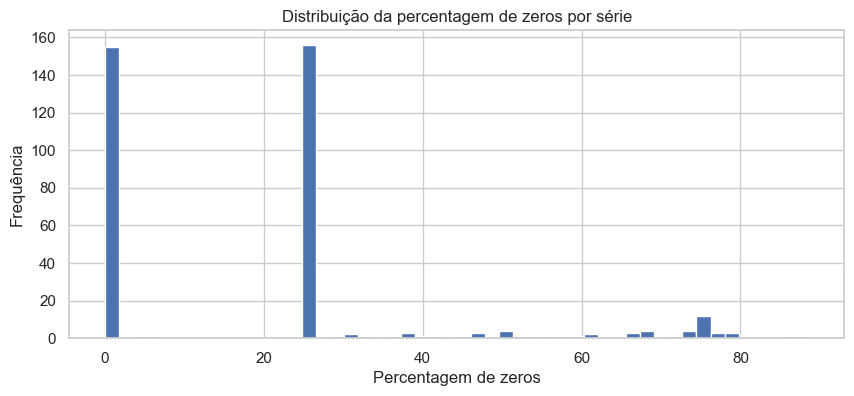

In [41]:
plt.figure(figsize=(10, 4))
plt.hist(zeros_pct_benchmark, bins=50)

plt.title("Distribuição da percentagem de zeros por série")
plt.xlabel("Percentagem de zeros")
plt.ylabel("Frequência")

plt.show()

## Conclusões iniciais sobre o benchmark

- O dataset benchmark encontra-se organizado em formato matricial, com múltiplas séries temporais já alinhadas temporalmente.
- A frequência temporal dominante deverá corresponder a 15 minutos, à semelhança de muitos cenários de consumo elétrico.
- A análise da percentagem de zeros por série é relevante, uma vez que algumas séries podem apresentar atividade reduzida ou descontinuidades.
- As estatísticas descritivas, histogramas, boxplots e agregações temporais permitem caracterizar o comportamento global e individual das séries.
- A autocorrelação e o perfil médio diário ajudam a identificar padrões temporais regulares, úteis para fases posteriores de pré-processamento e deteção de anomalias.

In [42]:
estatisticas_por_serie_benchmark = df_pivot_benchmark.describe().T
estatisticas_por_serie_benchmark.to_csv("../results/estatisticas_por_serie_benchmark.csv")

missing_pct_benchmark.sort_values().to_csv("../results/missing_pct_por_serie_benchmark.csv")
zeros_pct_benchmark.sort_values().to_csv("../results/zeros_pct_por_serie_benchmark.csv")
consumo_medio_por_serie.to_csv("../results/consumo_medio_por_serie_benchmark.csv")